In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.ticker import AutoMinorLocator

from statsmodels.tsa.seasonal import seasonal_decompose

import helper

# Section b: DataAssignment1

First: for each method, consider
- estimation set t = 1,...,30
- forecast set t = 31,...,40
- tune (when needed) using t = 31,...,40
- forecast precision 

Based on all nine time variables, make a recommendation. 

In [ ]:
df_1 = pd.read_excel("DataAssignment1.xlsx")

N = 50
y_list = [df_1.iloc[:, i].astype(float).to_numpy() for i in range(9)]
y_names = [f"y_{i+1}" for i in range(9)]

t_est_end = 30        
t_fc_start = 30      
t_fc_end = 40

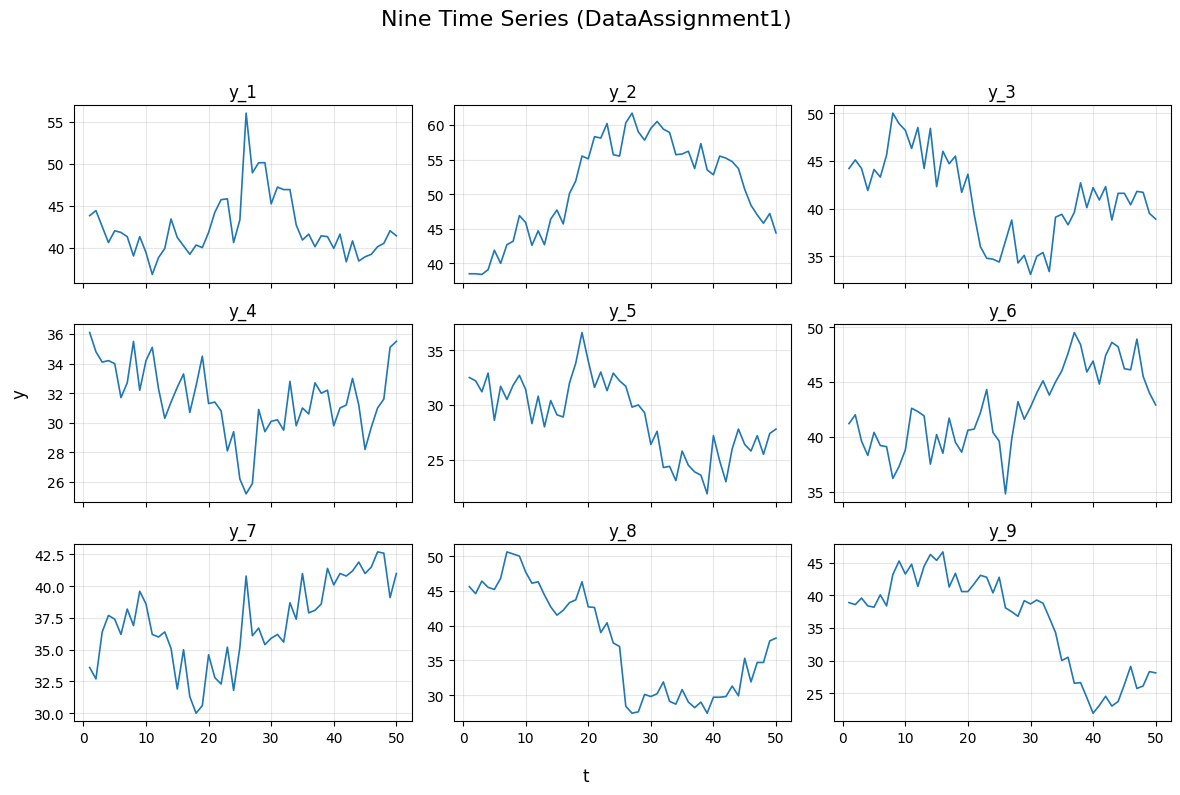

In [ ]:
T = len(y_list[0])
t = np.arange(1, T + 1)

# -----------------------------
# Plot 9 series in a 3x3 grid
# -----------------------------
fig, axes = plt.subplots(3, 3, figsize=(12, 8), sharex=True)
axes = axes.ravel()

for i, (y, name) in enumerate(zip(y_list, y_names)):
    ax = axes[i]
    ax.plot(t, y, linewidth=1.2)
    ax.set_title(name)
    ax.grid(True, alpha=0.3)

# common labels
fig.suptitle("Nine Time Series", fontsize=16)
fig.supxlabel("t")
fig.supylabel("y")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [30]:
#evaluation function
def metrics(y_true, y_hat):
    u = y_true - y_hat
    return {
        "ME": np.mean(u),
        "MAE": np.mean(np.abs(u)),
        "MAPE": np.mean(100 * np.abs(u) / np.abs(y_true)),
        "MSE": np.mean(u**2),
    }

all_results = {} #store in dictionary 
exp_alpha_store = {} #store parameters for part 2
exp_alpha_rolling_last_store = {}
holt_param_store = {} #store parameters for part 2
holt_param_rolling_last_store = {}

In [ ]:
#loop over all time series
for idx, y in zip(y_names, y_list):
    y_est = y[:t_est_end]
    y_eval = y[t_fc_start:t_fc_end]

    forecasts = {} #store in dictionary

    #average
    y_avg = np.mean(y_est)
    f_avg = np.full_like(y_eval, y_avg) #forecast = average
    forecasts["Average"] = f_avg

    #running average
    f_avg = helper.running_average_forecast(y)
    forecasts["Running Average"] = f_avg[t_fc_start:t_fc_end]

    #running trend
    f_rt, _, _ = helper.running_trend_forecast(y)
    forecasts["Running Trend"] = f_rt[t_fc_start:t_fc_end]

    #random walk
    f_rw = helper.lag_forecast(y)
    forecasts['Random Walk'] = f_rw[t_fc_start:t_fc_end]
    
    #random walk with drift
    _, rw_drift, _ = helper.random_walk_plus_drift_forecast(y)
    forecasts['Random Walk + Drift'] = rw_drift[t_fc_start:t_fc_end]

    #exponential smoothing (tuned based on mse, fixed window 31-40)
    alpha_candidates = np.linspace(1e-4, 1, 2000) #(0,1]
    best_alpha, best_mse = None, np.inf
    for alpha in alpha_candidates:
        f_es = helper.exp_smoothing_forecast(y[:t_fc_end], alpha)
        f_eval = f_es[t_fc_start:t_fc_end]
        mse = np.mean((y_eval - f_eval)**2)
        if mse < best_mse:
            best_alpha, best_mse = alpha, mse
    
    f_es = helper.exp_smoothing_forecast(y, best_alpha)[t_fc_start:t_fc_end]
    forecasts[f'Exponentional Smoothing (alpha = {best_alpha:.3f})'] = f_es

    exp_alpha_store[idx] = best_alpha

    #exponential smoothing (retuned with most recent data, rolling window size 10)
    f_es_rolling = np.full(10, np.nan)
    alpha_candidates = np.linspace(1e-4, 1, 2000) #(0,1]
    alpha_last = None
    for t in range(t_fc_start, t_fc_end):
        y_sub = y[:t]
        best_alpha, best_mse = None, np.inf

        for alpha in alpha_candidates:
            f_sub = helper.exp_smoothing_forecast(y_sub, alpha)
            f_window = f_sub[t-10:t]
            y_window = y[t-10:t]
        
            mse = np.mean((y_window - f_window)**2)
            if mse < best_mse:
                best_alpha, best_mse = alpha, mse
        
        alpha_last = best_alpha
        y_sub_t = y[:t+1]
        f_sub_best = helper.exp_smoothing_forecast(y_sub_t, best_alpha)
        f_es_rolling[t - t_fc_start] = f_sub_best[-1]
    
    forecasts[f'Exponentional Smoothing (retuned)'] = f_es_rolling
    exp_alpha_rolling_last_store[idx] = alpha_last

    #holt winters/double exponential smoothing (tuned)
    # alpha_path, beta_path, F_hat, u_hat, loss_path = helper.estimate_alpha_beta_holt_winters(
    #     y_est,
    #     criterion="SSE",
    #     grid_n=201,
    #     eps=1e-3,
    # ) #like in a

    # alpha = alpha_path[~np.isnan(alpha_path)][-1]
    # beta = beta_path[~np.isnan(beta_path)][-1]
    # f_holt = helper.holt_fitted_forecast_series(y, alpha, beta)
    # f_holt[:2] = np.nan
    # forecasts['Holt Winters'] = f_holt[t_fc_start: t_fc_end]

    # holt_param_store[idx] = (alpha, beta)



    #holt winters/double exponential smoothing (tuned based on fixed window 31-40)
    grid = np.linspace(1e-3, 1.0, 200)
    best_alpha, best_beta, best_mse = None, None, np.inf

    for alpha in grid:
        for beta in grid:
            f_hw = helper.holt_fitted_forecast_series(y[: t_fc_end], alpha, beta)
            f_eval = f_hw[t_fc_start:t_fc_end]
            mse = np.mean((y_eval - f_eval)**2)

            if mse < best_mse:
                best_alpha, best_beta, best_mse = alpha, beta, mse
    
    f_hw = helper.holt_fitted_forecast_series(y, best_alpha, best_beta)[t_fc_start:t_fc_end]
    forecasts[f'Holt-Winters (alpha = {best_alpha:.3f}, beta = {best_beta:.3f})'] = f_hw

    holt_param_store[idx] = (best_alpha, best_beta)

    #holt winters/double exponential smoothing (retuned with most recent data, rolling window size 10)
    grid = np.linspace(1e-3, 1.0, 200)
    f_hw_rolling = np.full(10, np.nan)
    holt_param_last = None
    
    for t in range(t_fc_start, t_fc_end):
        best_alpha, best_beta, best_mse = None, None, np.inf
        y_sub = y[:t]

        for alpha in grid:
            for beta in grid:
                f_sub = helper.holt_fitted_forecast_series(y_sub, alpha, beta)
                f_window = f_sub[t-10:t]
                y_window = y_sub[t-10:t]

                mse = np.mean((y_window - f_window)**2)
                if mse < best_mse:
                    best_alpha, best_beta, best_mse = alpha, beta, mse
        
        holt_param_last = (best_alpha, best_beta)
        y_sub_t = y[:t+1]
        f_sub_best = helper.holt_fitted_forecast_series(y_sub_t, best_alpha, best_beta)
        f_hw_rolling[t - t_fc_start] = f_sub_best[-1]
    
    forecasts[f'Holt-Winters (retuned)'] = f_hw_rolling
    holt_param_rolling_last_store[idx] = holt_param_last

    #evaluation
    res = {}
    for method, forecast in forecasts.items():
        res[method] = metrics(y_eval, forecast)

    all_results[idx] = res

In [23]:
exp_alpha_store

{'y_1': np.float64(0.8739495747873938),
 'y_2': np.float64(0.6433573286643322),
 'y_3': np.float64(0.6263505252626314),
 'y_4': np.float64(0.07012801400700351),
 'y_5': np.float64(0.620848324162081),
 'y_6': np.float64(1.0),
 'y_7': np.float64(0.4912964982491246),
 'y_8': np.float64(0.3497398699349675),
 'y_9': np.float64(1.0)}

In [24]:
holt_param_store

{'y_1': (np.float64(0.6636532663316583), np.float64(0.29718592964824125)),
 'y_2': (np.float64(0.14658291457286435), np.float64(0.8594371859296484)),
 'y_3': (np.float64(0.14156281407035176), np.float64(1.0)),
 'y_4': (np.float64(0.05120100502512563), np.float64(0.3624472361809046)),
 'y_5': (np.float64(0.006020100502512563), np.float64(0.3022060301507538)),
 'y_6': (np.float64(0.13152261306532664), np.float64(0.026100502512562816)),
 'y_7': (np.float64(0.026100502512562816), np.float64(0.5030100502512563)),
 'y_8': (np.float64(0.011040201005025126), np.float64(0.39256783919597993)),
 'y_9': (np.float64(0.03614070351758794), np.float64(1.0))}

In [20]:
#results

def normalize_method(name):
    name = name.lower()
    if "retuned" in name and ("smoothing" in name or "exponent" in name):
        return "ExpSmo (retuned)"
    elif "smoothing" in name or "exponent" in name:
        return "ExpSmo"
    elif "rw + drift" in name or "drift" in name:
        return "RW + Drift"
    elif "random walk" in name:
        return "Random Walk"
    elif "trend" in name:
        return "Running Trend"
    elif "running" in name:
        return "Running Avg"
    elif "average" in name:
        return "Average"
    elif "retuned" in name and "holt" in name:
        return "Holt-Winters (retuned)"
    elif "holt" in name:
        return "Holt-Winters"
    else:
        return name
    
panels = {}

for var in all_results:
    df_tmp = pd.DataFrame(all_results[var]).T
    df_tmp.index = [normalize_method(m) for m in df_tmp.index]
    panels[var] = df_tmp

all_methods = sorted(
    set().union(*[df.index.tolist() for df in panels.values()])
)
agg = {m: {"ME": [], "MAE": [], "MAPE": [], "MSE": []} for m in all_methods}

for var, df in panels.items():
    for m in all_methods:
        if m in df.index:
            for k in ["ME", "MAE", "MAPE", "MSE"]:
                agg[m][k].append(df.loc[m, k])

for var, df_res in panels.items():
    print(f"\nFORECAST RESULTS — {var}  (t = 31…40)")
    print("="*70)
    print(df_res.round(3).to_string())
    print("="*70)


FORECAST RESULTS — y_1  (t = 31…40)
                           ME    MAE   MAPE     MSE
Average                -0.030  2.478  5.686   7.788
Running Avg            -0.229  2.598  5.987   8.023
Running Trend          -3.708  3.778  9.171  19.690
Random Walk            -0.530  1.330  3.143   3.137
RW + Drift             -0.524  1.352  3.190   3.201
ExpSmo                 -0.657  1.246  2.965   3.047
ExpSmo (retuned)       -1.336  1.567  3.748   4.629
Holt-Winters            0.011  1.290  3.067   2.914
Holt-Winters (retuned) -2.770  3.095  7.340  12.781

FORECAST RESULTS — y_2  (t = 31…40)
                           ME    MAE    MAPE     MSE
Average                 6.927  6.927  12.114  54.220
Running Avg             5.886  5.886  10.228  43.539
Running Trend          -6.947  6.947  12.543  54.740
Random Walk            -0.670  1.690   3.036   4.701
RW + Drift             -1.233  1.924   3.464   5.862
ExpSmo                 -0.888  1.705   3.068   4.056
ExpSmo (retuned)       -0.739  1.64

In [25]:
#average results across variables
agg_df = pd.DataFrame({
    m: {k: np.mean(agg[m][k]) for k in agg[m] if len(agg[m][k]) > 0}
    for m in agg
}).T

print("\nAGGREGATED FORECAST PERFORMANCE (MEAN OVER y₁…y₉)")
print("=" * 80)
print(agg_df.round(4).to_string())
print("=" * 80)


AGGREGATED FORECAST PERFORMANCE (MEAN OVER y₁…y₉)
                            ME     MAE     MAPE      MSE
Average                -1.9270  5.8934  17.9616  53.5420
ExpSmo                 -0.1623  1.4836   4.2324   3.4784
ExpSmo (retuned)       -0.0380  1.7093   4.8302   4.6370
Holt-Winters           -0.0696  1.2009   3.4590   2.2496
Holt-Winters (retuned) -0.2054  1.8914   5.2853   5.8300
RW + Drift             -0.0730  1.6736   4.7296   4.4315
Random Walk            -0.1211  1.6367   4.6769   4.2190
Running Avg            -1.7435  5.3121  16.1769  43.2808
Running Trend          -0.9041  3.9710  11.1801  23.3461


Recommendation rule: choose model with lowest MAE / MSE / MAPE jointly. Based on the above aggregated forecsat performances presented, the tuned Exponential Smoothing model satisfied this criterion as the MAE, MSE, and MAPE are the lowest across all models. Hence, the tuned Exponential Smoothing model is the recommended choice.

Second:
- t = 41,...,50
- re-assess the forecast precisions
- forecast precision

Based on all nine time variables, make a recommendation. Is there a difference?

In [27]:
t_fc2_start = 40  
t_fc2_end   = 50 
all_results_2 = {}

In [ ]:
for idx, y in zip(y_names, y_list):
    y_eval = y[t_fc2_start:t_fc2_end]
    forecasts = {}

    #average
    y_avg = np.mean(y[:t_est_end])
    forecasts["Average"] = np.full_like(y_eval, y_avg)

    #running average
    f_avg = helper.running_average_forecast(y)
    forecasts["Running Average"] = f_avg[t_fc2_start:t_fc2_end]

    #running trend
    f_rt = helper.running_trend_forecast(y)
    forecasts["Running Trend"] = f_avg[t_fc2_start:t_fc2_end]

    #random walk
    f_rw = helper.lag_forecast(y)
    forecasts["Random Walk"] = f_rw[t_fc2_start:t_fc2_end]

    #random walk with drift
    _, rw_drift, _ = helper.random_walk_plus_drift_forecast(y)
    forecasts["Random Walk + Drift"] = rw_drift[t_fc2_start:t_fc2_end]

    #exponential smoothing (fixed alpha)
    alpha = exp_alpha_store[idx]
    f_es = helper.exp_smoothing_forecast(y, alpha)
    forecasts[f'Exponentional Smoothing (alpha = {alpha:.3f})'] = \
        f_es[t_fc2_start:t_fc2_end]
    
    #exponential smoothing (fixed alpha)

    #holt winter (fixed parameters)
    alpha, beta = holt_param_store[idx]
    f_holt = helper.holt_fitted_forecast_series(y, alpha, beta)
    f_holt[:2] = np.nan
    forecasts["Holt Winters"] = f_holt[t_fc2_start:t_fc2_end]

    #evaluation
    res = {}
    for method, forecast in forecasts.items():
        res[method] = metrics(y_eval, forecast)

    all_results_2[idx] = res

In [29]:
#results 
panels_2 = {}

for var in all_results_2:
    df_tmp = pd.DataFrame(all_results_2[var]).T
    df_tmp.index = [normalize_method(m) for m in df_tmp.index]
    panels_2[var] = df_tmp

for var, df_res in panels_2.items():
    print(f"\nFORECAST RESULTS — {var}  (t = 41…50)")
    print("="*70)
    print(df_res.round(3).to_string())
    print("="*70)



FORECAST RESULTS — y_1  (t = 41…50)
                 ME    MAE   MAPE    MSE
Average      -2.800  2.800  7.090  9.498
Running Avg  -2.491  2.491  6.324  8.079
Random Walk   0.150  1.410  3.538  2.971
RW + Drift    0.239  1.466  3.676  3.071
ExpSmo        0.157  1.286  3.227  2.491
Holt-Winters  0.450  1.382  3.449  2.374

FORECAST RESULTS — y_2  (t = 41…50)
                 ME    MAE   MAPE     MSE
Average       0.807  3.700  7.279  16.779
Running Avg  -1.083  3.840  7.826  17.183
Random Walk  -0.840  1.660  3.373   3.612
RW + Drift   -1.136  1.851  3.752   4.158
ExpSmo       -1.258  1.892  3.872   4.851
Holt-Winters -1.222  2.599  5.257   9.874

FORECAST RESULTS — y_3  (t = 41…50)
                 ME    MAE   MAPE    MSE
Average      -1.380  1.414  3.560  3.383
Running Avg  -0.457  1.057  2.646  1.698
Random Walk  -0.330  1.450  3.591  3.235
RW + Drift   -0.258  1.450  3.586  3.263
ExpSmo       -0.348  1.295  3.219  2.273
Holt-Winters -0.921  1.585  3.919  4.433

FORECAST RESULTS — y

In [13]:
#average results
all_methods_2 = sorted(
    set().union(*[df.index.tolist() for df in panels_2.values()])
)

agg_2 = {m: {"ME": [], "MAE": [], "MAPE": [], "MSE": []} for m in all_methods_2}

for var, df in panels_2.items():
    for m in all_methods_2:
        if m in df.index:
            for k in ["ME", "MAE", "MAPE", "MSE"]:
                agg_2[m][k].append(df.loc[m, k])

agg_df_2 = pd.DataFrame({
    m: {k: np.mean(agg_2[m][k]) for k in agg_2[m] if len(agg_2[m][k]) > 0}
    for m in agg_2
}).T

print("\nAGGREGATED FORECAST PERFORMANCE (MEAN OVER y₁…y₉) — PART 2")
print("=" * 80)
print(agg_df_2.round(4).to_string())
print("=" * 80)



AGGREGATED FORECAST PERFORMANCE (MEAN OVER y₁…y₉) — PART 2
                  ME     MAE     MAPE      MSE
Average      -2.2337  5.6300  17.5362  51.7748
ExpSmo        0.2208  1.5244   4.2689   3.7084
Holt-Winters  0.3247  1.5668   4.3996   4.0172
RW + Drift    0.1358  1.6241   4.6263   3.8657
Random Walk   0.0856  1.5433   4.3970   3.5926
Running Avg  -1.5696  4.1273  12.7750  29.0733


Based on the above aggregated forecsat performances presented, the tuned Exponential Smoothing model is no longer the model with lowest MSE and thus the recommendation must change. In the new results, there is no inferior model that minimizes a majority of the metric. The Random Walk actually has the lowest MSE, while Holt-Winters has the lowest MAE. The Random Walk is also a close runner-up in MAE and MAPE. This tells us that its simplicity overtakes the complex methods and perhaps avoids overfitting. Hence, the Random Walk model should now to be recommended. 